Focus on the implications of SC-PFAS

In [ ]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import myfunction as mf
import myaccess as ma
import os
from path_config import *


import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


def filter_df_by_conditions(df_data, df_select, conditions: dict, logic='and'):

    def standardize_coords(df):
        df = df.copy()
        if 'lon_grid' in df.columns and 'lat_grid' in df.columns:
            df['lon'] = df['lon_grid']
            df['lat'] = df['lat_grid']
        elif 'lon' not in df.columns or 'lat' not in df.columns:
            raise ValueError("DataFrame must contain either ('lon', 'lat') or ('lon_grid', 'lat_grid')")
        return df

    df_data_std = standardize_coords(df_data)
    df_select_std = standardize_coords(df_select)


    if logic == 'and':
        mask = pd.Series(True, index=df_select_std.index)
        for col, values in conditions.items():
            mask &= df_select_std[col].isin(values)
    elif logic == 'or':
        mask = pd.Series(False, index=df_select_std.index)
        for col, values in conditions.items():
            mask |= df_select_std[col].isin(values)
    else:
        raise ValueError("logic must be 'and' or 'or'")


    selected_coords = df_select_std[mask][['lon', 'lat']].drop_duplicates()


    filtered_df = pd.merge(df_data_std, selected_coords, on=['lon', 'lat'], how='inner')

    return filtered_df


In [ ]:
df_pop_one = pd.read_csv(path_part4_grid + 'population_year.csv')

df_pop_one['pop'] = df_pop_one['pop'] / 10000


df_pop_one = df_pop_one.pivot(index=['lon', 'lat'], columns='year', values='pop').reset_index()
print(df_pop_one.head())

df_pop_one['pop_type'] = np.where(df_pop_one.loc[:, 2000:2020].sum(axis=1) == 0, 0, 1)
df_pop_one.to_csv(path_parts_temp + 'population_year_wide.csv', index=False)


year    lon   lat  2000  2001  2002  2003  2004  2005  2006  2007  ...  2011  \
0    -180.0 -90.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   0.0   
1    -180.0 -89.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   0.0   
2    -180.0 -88.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   0.0   
3    -180.0 -87.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   0.0   
4    -180.0 -86.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   0.0   

year  2012  2013  2014  2015  2016  2017  2018  2019  2020  
0      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
1      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
2      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
3      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
4      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  

[5 rows x 23 columns]


In [ ]:
df_pop = pd.read_csv(path_parts_temp + 'population_year_wide.csv')
df_ocean = pd.read_csv(path_file_nc + 'ocean.csv')
df_inland = pd.read_csv(path_file_nc + 'inland_water.csv')
df_country = pd.read_csv(path_file_csv + 'country_id.csv')
df_coast = pd.read_csv(path_file_nc + 'coast_distance.csv')

df_pop = pd.merge(df_pop, df_ocean[['lon', 'lat', 'ocean_water']], on=['lon', 'lat'], how='left')
df_pop = pd.merge(df_pop, df_inland[['lon', 'lat', 'inland_water']], on=['lon', 'lat'], how='left')
df_pop = pd.merge(df_pop, df_country[['lon', 'lat', 'country_id']], on=['lon', 'lat'], how='left')
df_pop = pd.merge(df_pop, df_coast[['lon', 'lat', 'coast_distance']], on=['lon', 'lat'], how='left')


df_pop['water'] = np.where((df_pop['ocean_water'] == 1) | (df_pop['inland_water'] == 1), 1, 0)
df_pop.to_csv(path_parts_temp + 'grid_re_all.csv', index=False)
df_pop_select = df_pop[['lon', 'lat', 'pop_type', 'water', 'country_id', 'ocean_water', 'inland_water', 'coast_distance']].copy()

df_pop_select['country_id'] = df_pop_select['country_id'].fillna(0)
df_pop_select.to_csv(path_parts_data + 'grid_re.csv', index=False)

In [ ]:
import numpy as np
import pandas as pd
from netCDF4 import Dataset

distance_path = r'C:\Users\dell\OneDrive\file\nc\coast_distance_1x1.nc'
distance_ds = Dataset(distance_path)


lon_distance = distance_ds.variables['lon'][:]
lat_distance = distance_ds.variables['lat'][:]
distance_type = distance_ds.variables['coast_distance'][:]


distance_df = pd.DataFrame({
    'lon': np.repeat(lon_distance, len(lat_distance)),
    'lat': np.tile(lat_distance, len(lon_distance)),
    'coast_distance': distance_type.flatten()
})


distance_df.to_csv(r'C:\Users\dell\OneDrive\file\nc\coast_distance.csv', index=False)


distance_ds.close()





In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

def draw_year_lm(df, path_save, int_max_y=20, str_unit='ng/l'):
    sns.set_theme(style="ticks")
    df_hem_line = df.copy()
    x = "year"
    y = "value"
    hue = "type"
    order = ["HFPO-DA", 'PFOA']

    palette = {"HFPO-DA": "#4f9c8b", "PFOA": "#4d8cbf"}
    ax = sns.lmplot(
        data=df_hem_line,
        x=x, y=y, hue=hue,
        height=5,
        palette=palette,legend=False, scatter=False,
        ci=95,
    )
    ax.set(ylim=(0,int_max_y))

    plt.xlabel('', fontsize=18)
    plt.ylabel("", fontsize=18)



    ax1 = ax.axes[0,0]
    df_hum_data1 = df_hem_line[df_hem_line[hue]==order[1]]
    slope, intercept, r_value, p_value, std_err = stats.linregress(df_hum_data1[x], df_hum_data1[y])
    reg_eq = "y = {:.4f}x + {:.4f}".format(slope, intercept)
    annot = "{}\np = {:.2e}\n{}".format(order[1], p_value, reg_eq)  # 修改此处
    ax1.annotate(annot, xy=(0.58, 0.99), xycoords="axes fraction",
                        fontsize=12, ha="left", va="top")

    ax2 = ax.axes[0,0]
    df_hum_data2 = df_hem_line[df_hem_line[hue]==order[0]]
    slope2, intercept2, r_value2, p_value2, std_err2 = stats.linregress(df_hum_data2[x], df_hum_data2[y])
    reg_eq2 = "y = {:.4f}x + {:.4f}".format(slope2, intercept2)
    annot2 = "{}\np = {:.2e}\n{}".format(order[0], p_value2, reg_eq2)  # 修改此处
    ax2.annotate(annot2, xy=(0.05, 0.99), xycoords="axes fraction",
                        fontsize=12, ha="left", va="top")

    plt.gcf().set_size_inches(5, 3)




    ax = plt.gca()

    handles, labels = ax.get_legend_handles_labels()
    if isinstance(palette, dict):
        line_handles = [plt.Line2D([0], [0], color=palette[label], lw=2) for label in labels]
    else:

        line_handles = [plt.Line2D([0], [0], color=color, lw=2) for color in palette[:len(labels)]]
    plt.yticks(fontsize=16)
    plt.xticks(fontsize=16)
    plt.subplots_adjust(left=0.15,right=0.95,bottom=0.15,top=0.7)

    plt.savefig(path_save, dpi = 180)
    plt.show()
    return print('okk')

def draw_year_line(data, path_save, int_max_y=20,  str_unit='ng/l'):
    custom_params = {"axes.spines.right": False, "axes.spines.top": False}
    sns.set_theme(style="ticks", rc=custom_params)
    fig, ax = plt.subplots()
    plt.gcf().set_size_inches(5, 3)
    sns.lineplot(x="year", y="HFPO-DA", data=data, color="#4f9c8b", label="HFPO-DA", marker='D', legend=False)
    sns.lineplot(x="year", y="PFOA", data=data, color="#4d8cbf", label="PFOA", marker='D', legend=False)


    ax.set(ylim=(0,int_max_y))
    plt.xlabel("", fontsize=18)

    plt.ylabel("", fontsize=18)

    plt.yticks(fontsize=16)
    plt.xticks(fontsize=16)


    plt.subplots_adjust(left=0.15,right=0.95,bottom=0.15,top=0.7)
    plt.savefig(path_save, dpi = 300)
    return 'okk'

In [2]:
combined_data = pd.read_csv(path_part3_sw + 'sw_lgbm_output/final_file/sw_merge.csv')
print(combined_data.head())
print(combined_data.columns)

   lon_grid  lat_grid     value  year     type  country_id     region
0      -179       -89  2.590435  2000  LC-PFAS         0.0  High Seas
1      -178       -89  2.574285  2000  LC-PFAS         0.0  High Seas
2      -177       -89  2.342963  2000  LC-PFAS         0.0  High Seas
3      -176       -89  2.565040  2000  LC-PFAS         0.0  High Seas
4      -175       -89  2.473593  2000  LC-PFAS         0.0  High Seas
Index(['lon_grid', 'lat_grid', 'value', 'year', 'type', 'country_id',
       'region'],
      dtype='object')


In [ ]:


sw_combined_data = pd.read_csv(path_part3_sw + 'sw_lgbm_output/final_file/sw.csv')

df_grid_re = pd.read_csv(path_parts_data + 'grid_re.csv')
df_sw = filter_df_by_conditions(sw_combined_data, df_grid_re,
                                conditions={"inland_water": [1]})


sw_sub_two = df_sw[['year', 'HFPO-DA', 'PFOA']].copy()
sw_sub_one = sw_sub_two.melt(id_vars='year', var_name='type', value_name='value')

path_save_line = path_parts_fig +  'figs_sub_line.svg'
path_save_lm = path_parts_fig +  'figs_sub_lm.svg'


e:\progress\anaconda2\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


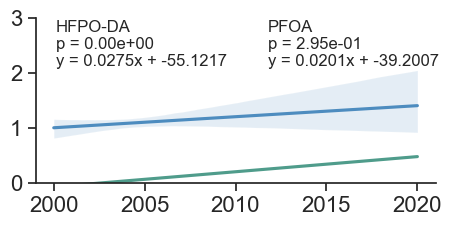

okk


'okk'

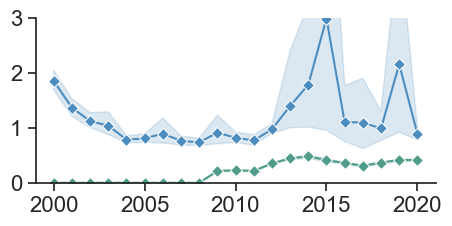

In [14]:
draw_year_lm(sw_sub_one, path_save_lm, 3, 'ng/g')
draw_year_line(sw_sub_two, path_save_line, 3,'ng/g')

In [ ]:

sw_combined_data = pd.read_csv(path_part3_sw + 'sw_lgbm_output/final_file/sw.csv')
sw_sub_two = sw_combined_data[['year', 'HFPO-DA', 'PFOA']].copy()
sw_sub_one = sw_sub_two.melt(id_vars='year', var_name='type', value_name='value')

path_save_line = path_parts_fig +  'figs_sub_line.svg'
path_save_lm = path_parts_fig +  'figs_sub_lm.svg'


In [ ]:
def draw_year_lm(df, path_save, int_max_y=20, str_unit='ng/l'):
    sns.set_theme(style="ticks")
    df_hem_line = df.copy()
    x = "year"
    y = "value"
    hue = "type"
    order = ["LC-PFAS", 'SC-PFAS']
    color_select = ["#e76361", "#808dae"]
    palette = {"LC-PFAS": "#4f9c8b", "SC-PFAS": "#4d8cbf"}
    ax = sns.lmplot(
        data=df_hem_line,
        x=x, y=y, hue=hue,
        height=5,
        palette=palette,legend=False, scatter=False,
        ci=95,
    )
    ax.set(ylim=(0,int_max_y))

    plt.xlabel('', fontsize=18)
    plt.ylabel("", fontsize=18)

    ax1 = ax.axes[0,0]
    df_hum_data1 = df_hem_line[df_hem_line[hue]==order[1]]
    slope, intercept, r_value, p_value, std_err = stats.linregress(df_hum_data1[x], df_hum_data1[y])
    reg_eq = "y = {:.4f}x + {:.4f}".format(slope, intercept)
    annot = "{}\np = {:.2e}\n{}".format(order[1], p_value, reg_eq)  # 修改此处
    ax1.annotate(annot, xy=(0.58, 0.99), xycoords="axes fraction",
                        fontsize=12, ha="left", va="top")

    ax2 = ax.axes[0,0]
    df_hum_data2 = df_hem_line[df_hem_line[hue]==order[0]]
    slope2, intercept2, r_value2, p_value2, std_err2 = stats.linregress(df_hum_data2[x], df_hum_data2[y])
    reg_eq2 = "y = {:.4f}x + {:.4f}".format(slope2, intercept2)
    annot2 = "{}\np = {:.2e}\n{}".format(order[0], p_value2, reg_eq2)  # 修改此处
    ax2.annotate(annot2, xy=(0.05, 0.99), xycoords="axes fraction",
                        fontsize=12, ha="left", va="top")

    plt.gcf().set_size_inches(5, 3)

    ax = plt.gca()

    handles, labels = ax.get_legend_handles_labels()
    if isinstance(palette, dict):
        line_handles = [plt.Line2D([0], [0], color=palette[label], lw=2) for label in labels]
    else:

        line_handles = [plt.Line2D([0], [0], color=color, lw=2) for color in palette[:len(labels)]]

    plt.yticks(fontsize=16)
    plt.xticks(fontsize=16)
    plt.subplots_adjust(left=0.15,right=0.95,bottom=0.15,top=0.7)

    plt.savefig(path_save, dpi = 180)
    plt.show()
    return print('okk')

def draw_year_line(data, path_save, int_max_y=20,  str_unit='ng/l'):
    custom_params = {"axes.spines.right": False, "axes.spines.top": False}
    sns.set_theme(style="ticks", rc=custom_params)
    fig, ax = plt.subplots()
    plt.gcf().set_size_inches(5, 3)


    sns.lineplot(x="year", y="value", data=data, color="#555c6c", label="Sum-PFAS", marker='D', legend=False)
    sns.lineplot(x="year", y="lc_value", data=data, color="#4f9c8b", label="LC-PFAS", marker='D', legend=False)
    sns.lineplot(x="year", y="sc_value", data=data, color="#4d8cbf", label="SC-PFAS", marker='D', legend=False)


    ax.set(ylim=(0,int_max_y))
    plt.xlabel("", fontsize=18)

    plt.ylabel("", fontsize=18)

    plt.yticks(fontsize=16)
    plt.xticks(fontsize=16)


    plt.subplots_adjust(left=0.15,right=0.95,bottom=0.15,top=0.7)
    plt.savefig(path_save, dpi = 300)
    return 'okk'

['High Seas', 'Europe', 'Pacific', 'Africa', 'Asia', 'North America', 'South America'] 7


e:\progress\anaconda2\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


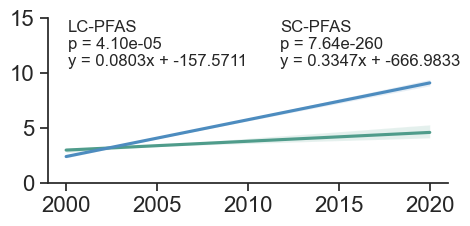

okk


'okk'

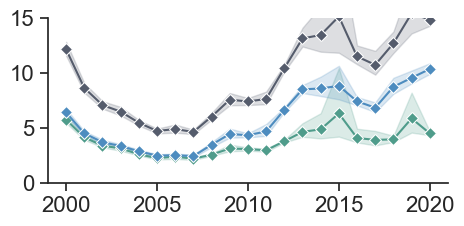

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
combined_data_raw = pd.read_csv(path_part3_sw + 'sw_lgbm_output/final_file/sw_merge.csv')

sw_combined_data_raw = pd.read_csv(path_part3_sw + 'sw_lgbm_output/final_file/sw.csv')

df_grid_re = pd.read_csv(path_parts_data + 'grid_re.csv')
combined_data = filter_df_by_conditions(combined_data_raw, df_grid_re,
                                conditions={"inland_water": [1]})
sw_combined_data = filter_df_by_conditions(sw_combined_data_raw, df_grid_re,
                                conditions={"inland_water": [1]})
palette_colors = {"LC-PFAS": "#4f9c8b", "SC-PFAS": "#4d8cbf"}
list_regin = combined_data['region'].unique().tolist()
print(list_regin, len(list_regin))
path_save_line = path_parts_fig +  'figs5_sw_line.svg'
path_save_lm = path_parts_fig +  'figs5_sw_lm.svg'
draw_year_lm(combined_data, path_save_lm, 15, 'ng/g')
draw_year_line(sw_combined_data, path_save_line, 15,'ng/g')